E:\Anaconda\envs\matrix\lib\site-packages\tensorflow_addons\utils\tfa_eol_msg.py:23: UserWarning: 

TensorFlow Addons (TFA) has ended development and introduction of new features.
TFA has entered a minimal maintenance and release mode until a planned end of life in May 2024.
Please modify downstream libraries to take dependencies from other repositories in our TensorFlow community (e.g. Keras, Keras-CV, and Keras-NLP). 

For more information see: https://github.com/tensorflow/addons/issues/2807 

  warnings.warn(
E:\Anaconda\envs\matrix\lib\site-packages\tensorflow_addons\utils\ensure_tf_install.py:53: UserWarning: Tensorflow Addons supports using Python ops for all Tensorflow versions above or equal to 2.12.0 and strictly below 2.15.0 (nightly versions are not supported). 
 The versions of TensorFlow you are currently using is 2.10.0 and is not supported. 
Some things might work, some things might not.
If you were to encounter a bug, do not file an issue.
If you want to make sure you'

INFO:tensorflow:Mixed precision compatibility check (mixed_float16): OK
Your GPU will likely run quickly with dtype policy mixed_float16 as it has compute capability of at least 7.0. Your GPU: NVIDIA GeForce RTX 3070 Ti Laptop GPU, compute capability 8.6
Found 3600 images belonging to 5 classes.
Found 76 images belonging to 5 classes.
Found 81 images belonging to 5 classes.
Epoch 1/50
225/225 [==============================] - 109s 430ms/step - loss: 1.6476 - accuracy: 0.2475 - auc: 0.5542 - precision: 0.4286 - val_loss: 1.6173 - val_accuracy: 0.1974 - val_auc: 0.5257 - val_precision: 0.0000e+00 - lr: 0.0010
Epoch 2/50
225/225 [==============================] - 37s 164ms/step - loss: 1.5802 - accuracy: 0.2756 - auc: 0.5985 - precision: 0.5104 - val_loss: 1.5521 - val_accuracy: 0.3026 - val_auc: 0.6200 - val_precision: 0.0000e+00 - lr: 0.0010
Epoch 3/50
225/225 [==============================] - 30s 132ms/step - loss: 1.5398 - accuracy: 0.3089 - auc: 0.6443 - precision: 0.5911 - val_los

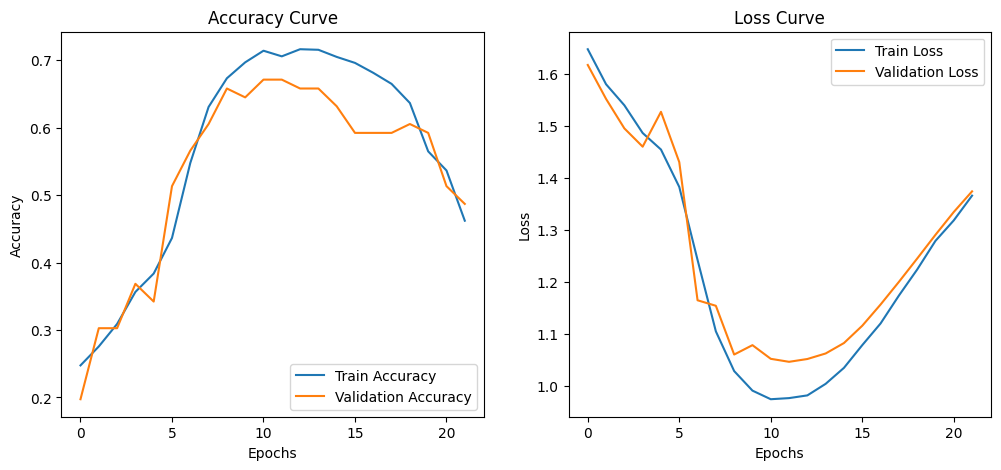

6/6 [==============================] - 1s 91ms/step
Accuracy: 0.5926
Precision: 0.5878
Recall: 0.5926
F1 Score: 0.5891


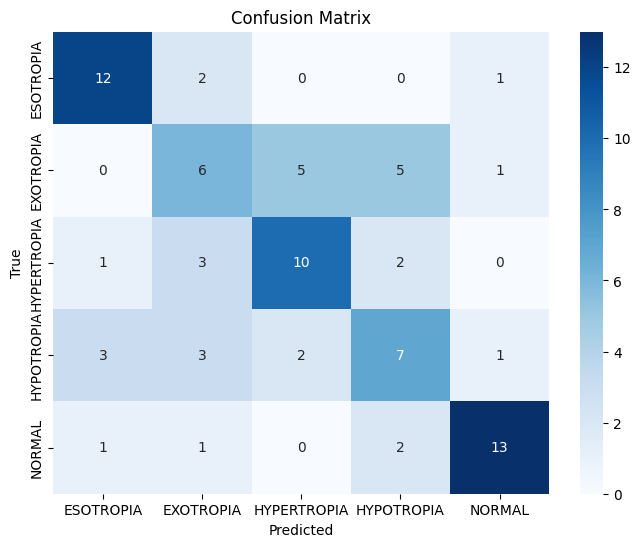

Strict AlexNet model training and evaluation complete.


In [1]:
import tensorflow as tf
import tensorflow_addons as tfa
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import gc
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, DepthwiseConv2D, MaxPooling2D, BatchNormalization, GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import LearningRateScheduler, ReduceLROnPlateau, EarlyStopping
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

# Enable mixed precision training
tf.keras.mixed_precision.set_global_policy('mixed_float16')

# Define dataset paths
train_data_dir = "E:/Projects/Strabismus/Final_Train_data"
val_data_dir = "E:/Projects/Strabismus/Split_Data/val"
test_data_dir = "E:/Projects/Strabismus/Split_Data/test"

# Image parameters
img_height, img_width = 227, 227
batch_size = 16
num_classes = 5  

# Data Augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)
val_test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical'
)

val_generator = val_test_datagen.flow_from_directory(
    val_data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical'
)

test_generator = val_test_datagen.flow_from_directory(
    test_data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

# Compute class weights
class_weights = compute_class_weight('balanced', classes=np.arange(num_classes), y=train_generator.classes)
class_weight_dict = dict(enumerate(class_weights))

# Clear unused variables to free memory
tf.keras.backend.clear_session()
gc.collect()

# Define strict AlexNet model
def AlexNet(input_shape, num_classes):
    model = Sequential([
        Conv2D(96, (11, 11), strides=4, padding='same', activation='relu', input_shape=input_shape),
        BatchNormalization(),
        MaxPooling2D((3, 3), strides=2),
        
        DepthwiseConv2D((5, 5), padding='same', activation='relu'),
        BatchNormalization(),
        MaxPooling2D((3, 3), strides=2),
        
        Conv2D(384, (3, 3), padding='same', activation='relu'),
        Conv2D(384, (3, 3), padding='same', activation='relu'),
        Conv2D(256, (3, 3), padding='same', activation='relu'),
        MaxPooling2D((3, 3), strides=2),
        
        GlobalAveragePooling2D(),
        Dense(4096, activation='relu'),
        Dropout(0.5),
        Dense(4096, activation='relu'),
        Dropout(0.5),
        Dense(num_classes, activation='softmax')
    ])
    return model

# Instantiate model
model = AlexNet((img_height, img_width, 3), num_classes)

# Define learning rate scheduler
def lr_scheduler(epoch, lr):
    if epoch < 5:
        return lr
    elif epoch < 15:
        return lr * 0.5
    else:
        return lr * 0.1

callback_lr = LearningRateScheduler(lr_scheduler)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, verbose=1)

# Optimizer
optimizer = tfa.optimizers.AdamW(learning_rate=0.001, weight_decay=1e-4)

# Compile model
model.compile(optimizer=optimizer, 
              loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1), 
              metrics=['accuracy', tf.keras.metrics.AUC(name='auc'), tf.keras.metrics.Precision(name='precision')])

# Define early stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train the model
history = model.fit(
    train_generator,
    epochs=50,
    validation_data=val_generator,
    class_weight=class_weight_dict,
    callbacks=[callback_lr, reduce_lr, early_stopping]
)

# Plot learning curves
def plot_learning_curves(history):
    plt.figure(figsize=(12, 5))
    
    # Accuracy plot
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.title('Accuracy Curve')
    plt.legend()
    
    # Loss plot
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Loss Curve')
    plt.legend()
    
    plt.show()

plot_learning_curves(history)

# Evaluate model on test data
y_pred_probs = model.predict(test_generator)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_generator.classes

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

# Print evaluation metrics
print(f"Accuracy: {accuracy:.4f}\nPrecision: {precision:.4f}\nRecall: {recall:.4f}\nF1 Score: {f1:.4f}")

# Plot Confusion Matrix
def plot_confusion_matrix(y_true, y_pred, class_names):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.show()

plot_confusion_matrix(y_true, y_pred, list(test_generator.class_indices.keys()))

print("Strict AlexNet model training and evaluation complete.")